<a href="https://colab.research.google.com/github/SubhanaJamil/Phylogenetic-Analysis-/blob/main/Kinesin_14_Family_Proteins_RAxML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install biopython

import os
import sys
import Bio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 17.3 MB/s eta 0:00:00


In [2]:
!apt-get install -qq -y mafft

!mafft --help

Extracting templates from packages: 100%
Selecting previously unselected package fonts-lato.
(Reading database ... 118251 files and directories currently installed.)
Preparing to unpack .../00-fonts-lato_2.0-2.1_all.deb ...
Unpacking fonts-lato (2.0-2.1) ...
Selecting previously unselected package netbase.
Preparing to unpack .../01-netbase_6.3_all.deb ...
Unpacking netbase (6.3) ...
Selecting previously unselected package libclone-perl.
Preparing to unpack .../02-libclone-perl_0.45-1build3_amd64.deb ...
Unpacking libclone-perl (0.45-1build3) ...
Selecting previously unselected package libdata-dump-perl.
Preparing to unpack .../03-libdata-dump-perl_1.25-1_all.deb ...
Unpacking libdata-dump-perl (1.25-1) ...
Selecting previously unselected package libencode-locale-perl.
Preparing to unpack .../04-libencode-locale-perl_1.05-1.1_all.deb ...
Unpacking libencode-locale-perl (1.05-1.1) ...
Selecting previously unselected package libhttp-date-perl.
Preparing to unpack .../05-libhttp-date-perl

In [3]:
import os

!wget -q https://github.com/conda-forge/miniforge/releases/latest/download/Miniforge3-Linux-x86_64.sh -O /tmp/miniforge.sh

!bash /tmp/miniforge.sh -b -p /usr/local/miniforge

!rm /tmp/miniforge.sh

os.environ["PATH"] = "/usr/local/miniforge/bin:" + os.environ["PATH"]

!conda --version

!conda config --set always_yes yes --set changeps1 no

!conda install -c conda-forge mamba

!conda install -c bioconda raxml-ng modeltest-ng --yes

PREFIX=/usr/local/miniforge
Unpacking bootstrapper...
Unpacking payload...
Extracting ca-certificates-2026.4.22-hbd8a1cb_0.conda
Extracting libgomp-15.2.0-he0feb66_18.conda
Extracting libzlib-1.3.2-h25fd6f3_2.conda
Extracting nlohmann_json-abi-3.12.0-h0f90c79_1.conda
Extracting pybind11-abi-11-hc364b38_1.conda
Extracting python_abi-3.13-8_cp313.conda
Extracting tzdata-2025c-hc9c84f9_1.conda
Extracting _openmp_mutex-4.5-20_gnu.conda
Extracting zstd-1.5.7-hb78ec9c_6.conda
Extracting ld_impl_linux-64-2.45.1-default_hbd61a6d_102.conda
Extracting libgcc-15.2.0-he0feb66_18.conda
Extracting bzip2-1.0.8-hda65f42_9.conda
Extracting c-ares-1.34.6-hb03c661_0.conda
Extracting keyutils-1.6.3-hb9d3cd8_0.conda
Extracting libexpat-2.7.5-hecca717_0.conda
Extracting libffi-3.5.2-h3435931_0.conda
Extracting libgcc-ng-15.2.0-h69a702a_18.conda
Extracting libiconv-1.18-h3b78370_2.conda
Extracting liblzma-5.8.3-hb03c661_0.conda
Extracting libmpdec-4.0.0-hb03c661_1.conda
Extracting libstdcxx-15.2.0-h934c35e_1

In [4]:
from Bio import SeqIO, Entrez

# Set email
Entrez.email = "subhanajamil3@gmail.com"

# Retrieve sequence
temp = Entrez.efetch(
    db="protein",
    rettype="fasta",
    id="1CZ7_A"
)

# Output FASTA file
aaseq_out = open("kinesin14_query.fasta",'w')

# Read sequence
aaseq = SeqIO.read(temp, format="fasta")

# Write sequence
SeqIO.write(aaseq, aaseq_out, "fasta")

# Close files
temp.close()
aaseq_out.close()

In [5]:
print("Sequence Length:")
print(len(aaseq))

print("\nDescription:")
print(aaseq.description)

print("\nAccession ID:")
print(aaseq.id)

print("\nSequence:")
print(aaseq.seq)

Sequence Length:
406

Description:
pdb|1CZ7|A Chain A, MICROTUBULE MOTOR PROTEIN NCD

Accession ID:
pdb|1CZ7|A

Sequence:
ALSTEVVHLRQRTEELLRCNEQQAAELETCKEQLFQSNMERKELHNTVMDLRGNIRVFCRIRPPLESEENRMCCTWTYHDESTVELQSIDAQAKSKMGQQIFSFDQVFHPLSSQSDIFEMVSPLIQSALDGYNICIFAYGQTGSGKTYTMDGVPESVGVIPRTVDLLFDSIRGYRNLGWEYEIKATFLEIYNEVLYDLLSNEQKDMEIRMAKNNKNDIYVSNITEETVLDPNHLRHLMHTAKMNRATASTAGNERSSRSHAVTKLELIGRHAEKQEISVGSINLVDLAGSESPKTSTRMTETKNINRSLSELTNVILALLQKQDHIPYRNSKLTHLLMPSLGGNSKTLMFINVSPFQDCFQESVKSLRFAASVNSCKMTKAKRNRYLNNSVANSSTQSNNSGSFDK


In [6]:
%%time

from Bio.Blast import NCBIWWW

result_handle = NCBIWWW.qblast(
    "blastp",
    "pdb",
    aaseq.seq,
    entrez_query='eukaryota[organism]'
)

CPU times: user 26.7 ms, sys: 5.16 ms, total: 31.9 ms
Wall time: 1min 1s


In [7]:
from Bio.Blast import NCBIXML

blast_record = NCBIXML.read(result_handle)

result_handle.close()

In [8]:
for alignment in blast_record.alignments:

    for hsp in alignment.hsps:

        print("Hit ID:")
        print(alignment.hit_id)

        print("Alignment Length:")
        print(hsp.align_length)

        print("E-value:")
        print(hsp.expect)

        print()

Hit ID:
pdb|2NCD|A
Alignment Length:
406
E-value:
0.0

Hit ID:
pdb|1CZ7|A
Alignment Length:
406
E-value:
0.0

Hit ID:
pdb|5W3D|A
Alignment Length:
406
E-value:
0.0

Hit ID:
pdb|1N6M|A
Alignment Length:
406
E-value:
0.0

Hit ID:
pdb|3U06|A
Alignment Length:
406
E-value:
0.0

Hit ID:
pdb|8YY2|C
Alignment Length:
406
E-value:
0.0

Hit ID:
pdb|8YUE|A
Alignment Length:
386
E-value:
0.0

Hit ID:
pdb|3L1C|A
Alignment Length:
380
E-value:
0.0

Hit ID:
pdb|5WDH|A
Alignment Length:
357
E-value:
2.89287e-88

Hit ID:
pdb|4ETP|A
Alignment Length:
407
E-value:
4.47896e-84

Hit ID:
pdb|1F9T|A
Alignment Length:
361
E-value:
1.17754e-83

Hit ID:
pdb|4GKR|A
Alignment Length:
373
E-value:
2.25776e-83

Hit ID:
pdb|3T0Q|A
Alignment Length:
350
E-value:
4.8202e-83

Hit ID:
pdb|5WDE|A
Alignment Length:
340
E-value:
2.11033e-79

Hit ID:
pdb|1F9W|A
Alignment Length:
351
E-value:
5.74133e-79

Hit ID:
pdb|1F9U|A
Alignment Length:
351
E-value:
6.8215e-79

Hit ID:
pdb|1F9V|A
Alignment Length:
351
E-value:
8.93008e

In [9]:
PIDcut = 1.00

for alignment in blast_record.alignments:

    for hsp in alignment.hsps:

        if (hsp.identities/hsp.align_length) <= PIDcut:

            print("Accession:", alignment.hit_id)

            print("Sequence Length:", alignment.length)

            print("Alignment Length:", hsp.align_length)

            print("E-value:", hsp.expect)

            print("Sequence Identity [%]:",
                  "{:.2f}".format(
                      100*hsp.identities/hsp.align_length
                  ))

            print("Coverage [%]:",
                  "{:.2f}".format(
                      100*sum(c.isalpha() for c in hsp.query)/len(aaseq)
                  ))

            print()

Accession: pdb|2NCD|A
Sequence Length: 420
Alignment Length: 406
E-value: 0.0
Sequence Identity [%]: 100.00
Coverage [%]: 100.00

Accession: pdb|1CZ7|A
Sequence Length: 406
Alignment Length: 406
E-value: 0.0
Sequence Identity [%]: 100.00
Coverage [%]: 100.00

Accession: pdb|5W3D|A
Sequence Length: 412
Alignment Length: 406
E-value: 0.0
Sequence Identity [%]: 99.75
Coverage [%]: 100.00

Accession: pdb|1N6M|A
Sequence Length: 409
Alignment Length: 406
E-value: 0.0
Sequence Identity [%]: 99.75
Coverage [%]: 100.00

Accession: pdb|3U06|A
Sequence Length: 412
Alignment Length: 406
E-value: 0.0
Sequence Identity [%]: 99.75
Coverage [%]: 100.00

Accession: pdb|8YY2|C
Sequence Length: 409
Alignment Length: 406
E-value: 0.0
Sequence Identity [%]: 99.51
Coverage [%]: 100.00

Accession: pdb|8YUE|A
Sequence Length: 390
Alignment Length: 386
E-value: 0.0
Sequence Identity [%]: 99.74
Coverage [%]: 95.07

Accession: pdb|3L1C|A
Sequence Length: 383
Alignment Length: 380
E-value: 0.0
Sequence Identity 

In [10]:
Entrez.email = "subhanajamil3@gmail.com"

with open("kinesin14_sequences.fasta", "a") as allhits_out:

    for alignment in blast_record.alignments[:20]:

        for hsp in alignment.hsps:

            if(hsp.identities/len(hsp.match)) <= PIDcut:

                print("Fetching:", alignment.hit_id)

                fetch = Entrez.efetch(
                    db="protein",
                    id=alignment.hit_id,
                    rettype="fasta"
                )

                allhits_seqs = SeqIO.read(fetch, format="fasta")

                SeqIO.write(
                    allhits_seqs,
                    allhits_out,
                    "fasta"
                )

                fetch.close()

allhits_out.close()

Fetching: pdb|2NCD|A
Fetching: pdb|1CZ7|A
Fetching: pdb|5W3D|A
Fetching: pdb|1N6M|A
Fetching: pdb|3U06|A
Fetching: pdb|8YY2|C
Fetching: pdb|8YUE|A
Fetching: pdb|3L1C|A
Fetching: pdb|5WDH|A
Fetching: pdb|4ETP|A
Fetching: pdb|1F9T|A
Fetching: pdb|4GKR|A
Fetching: pdb|3T0Q|A
Fetching: pdb|5WDE|A
Fetching: pdb|1F9W|A
Fetching: pdb|1F9U|A
Fetching: pdb|1F9V|A
Fetching: pdb|3KAR|A
Fetching: pdb|3H4S|A
Fetching: pdb|1SDM|A


In [11]:
!mafft kinesin14_sequences.fasta > aligned_kinesin14.fasta

nthread = 0
nthreadpair = 0
nthreadtb = 0
ppenalty_ex = 0
stacksize: 8192 kb
rescale = 1
Gap Penalty = -1.53, +0.00, +0.00



Making a distance matrix ..
    1 / 20
done.

Constructing a UPGMA tree (efffree=0) ... 
   10 / 20
done.

Progressive alignment 1/2... 
STEP    18 / 19  f
Reallocating..done. *alloclen = 1860
STEP    19 / 19  f
done.

Making a distance matrix from msa.. 
    0 / 20
done.

Constructing a UPGMA tree (efffree=1) ... 
   10 / 20
done.

Progressive alignment 2/2... 
STEP    18 / 19  f
Reallocating..done. *alloclen = 1904
STEP    19 / 19  f
done.

disttbfast (aa) Version 7.490
alg=A, model=BLOSUM62, 1.53, -0.00, -0.00, noshift, amax=0.0
0 thread(s)


Strategy:
 FFT-NS-2 (Fast but rough)
 Progressive method (guide trees were built 2 times.)

If unsure which option to use, try 'mafft --auto input > output'.
For more information, see 'mafft --help', 'mafft --man' and the mafft page.

The default gap scoring scheme has been changed in version 7.110 (2013 Oct).
It

In [12]:
from Bio import AlignIO

aln = AlignIO.read("aligned_kinesin14.fasta", "fasta")

print(aln)

Alignment with 20 rows and 511 columns
ELQAIHEKVKTEHAALSTEVVHLRQRTEELLRCNEQQAAELETC...--- pdb|2NCD|A
--------------ALSTEVVHLRQRTEELLRCNEQQAAELETC...--- pdb|1CZ7|A
--------MGSMHAALSTEVVHLRQRTEELLRCNEQQAAELETC...--- pdb|5W3D|A
-----------MHAALSTEVVHLRQRTEELLRCNEQQAAELETC...--- pdb|1N6M|A
--------MGSMHAALSTEVVHLRQRTEELLRCNEQQAAELETC...--- pdb|3U06|A
-----------MHAALSTEVVHLRQRTEELLRCNEQQAAELETC...--- pdb|8YY2|C
----------SMHAALSTEVVHLRQRTEELLRCNEQQAAELETC...--- pdb|8YUE|A
-----------MHAALSTEVVHLRQRTEELLRCNEQQAAELETC...--- pdb|3L1C|A
------------------------------------MGSSHH--...--- pdb|5WDH|A
--------GASKIAALKEKIAALKEKI-------AALKEKIKDT...--- pdb|4ETP|A
--------------------------------------------...--- pdb|1F9T|A
------------------------------------MAEEIK--...--- pdb|4GKR|A
--------------------------------------------...--- pdb|3T0Q|A
--------------------------------------------...--- pdb|5WDE|A
--------------------------------------------...--- pdb|1F9W|A
-------------------------------

In [13]:
from Bio import AlignIO
from Bio import SeqIO

aln = AlignIO.read("aligned_kinesin14.fasta", "fasta")

for fcol in range(aln.get_alignment_length()):

    if "-" not in aln[:, fcol]:
        position1 = fcol
        break

for lcol in reversed(range(aln.get_alignment_length())):

    if "-" not in aln[:, lcol]:
        position2 = lcol + 1
        break

with open("aligned_trimmed_kinesin14.fasta", "w") as handle:

    SeqIO.write(
        aln[:, position1:position2],
        handle,
        "fasta"
    )

In [14]:
from Bio import SeqIO

def sequence_cleaner(fasta_file, min_length=0):

    sequences = {}

    for seq_record in SeqIO.parse(fasta_file, "fasta"):

        sequence = str(seq_record.seq).upper()

        if len(sequence) >= min_length:

            if sequence not in sequences:

                sequences[sequence] = seq_record.id

            else:
                sequences[sequence] += "_" + seq_record.id

    with open("clear_" + fasta_file, "w+") as output_file:

        for sequence in sequences:

            output_file.write(
                ">" + sequences[sequence] +
                "\n" + sequence + "\n"
            )

    print("Duplicates Removed!")

sequence_cleaner('aligned_trimmed_kinesin14.fasta', 0)

Duplicates Removed!


In [15]:
!modeltest-ng -i clear_aligned_trimmed_kinesin14.fasta -d aa

                             _      _ _            _      _   _  _____ 
                            | |    | | |          | |    | \ | |/ ____|
         _ __ ___   ___   __| | ___| | |_ ___  ___| |_   |  \| | |  __ 
        | '_ ` _ \ / _ \ / _` |/ _ \ | __/ _ \/ __| __|  | . ` | | |_ |
        | | | | | | (_) | (_| |  __/ | ||  __/\__ \ |_   | |\  | |__| |
        |_| |_| |_|\___/ \__,_|\___|_|\__\___||___/\__|  |_| \_|\_____|
--------------------------------------------------------------------------------
ModelTest-NG v0.1.7 released on 17.03.2021 by The Exelixis Lab.
Written by Diego Darriba.
Contributors: Tomas Flouri, Alexey Kozlov, Benoit Morel, David Posada, 
              Alexandros Stamatakis.
Latest version: https://github.com/ddarriba/modeltest
--------------------------------------------------------------------------------

Physical cores: 1
Logical cores:  2
Memory:         12.7GB
Extensions:     AVX

Creating new checkpoint file: clear_aligned_trimmed_kinesin14.fasta.ckp


In [16]:
!raxml-ng \
--msa clear_aligned_trimmed_kinesin14.fasta \
--model LG+I+G4 \
--prefix K14_TREE \
--threads 2


RAxML-NG v. 2.0.1 released on 24.04.2026 by The Exelixis Lab.
Developed by: Oleksiy M. Kozlov and Alexandros Stamatakis.
Contributors: Diego Darriba, Tomas Flouri, Benoit Morel, Sarah Lutteropp, Ben Bettisworth,
              Julia Haag, Anastasis Togkousidis, Julius Wiegert, Christoph Stelz.
Latest version: https://github.com/amkozlov/raxml-ng
Questions/problems/suggestions? Please visit: https://groups.google.com/forum/#!forum/raxml

System: Intel(R) Xeon(R) CPU @ 2.20GHz, 1 cores, 12 GB RAM

RAxML-NG was called at 10-May-2026 21:55:54 as follows:

raxml-ng --msa clear_aligned_trimmed_kinesin14.fasta --model LG+I+G4 --prefix K14_TREE --threads 2

Analysis options:
  run mode: ML tree search (adaptive)
  start tree(s): adaptive
  random seed: 1778450154
  tip-inner: OFF
  pattern compression: ON
  per-rate scalers: OFF
  site repeats: ON
  logLH epsilon: general: 10.000000, brlen-triplet: 1000.000000
  stopping rule: OFF
  fast spr radius: AUTO
  spr subtree cutoff: 1.000000
  fast C

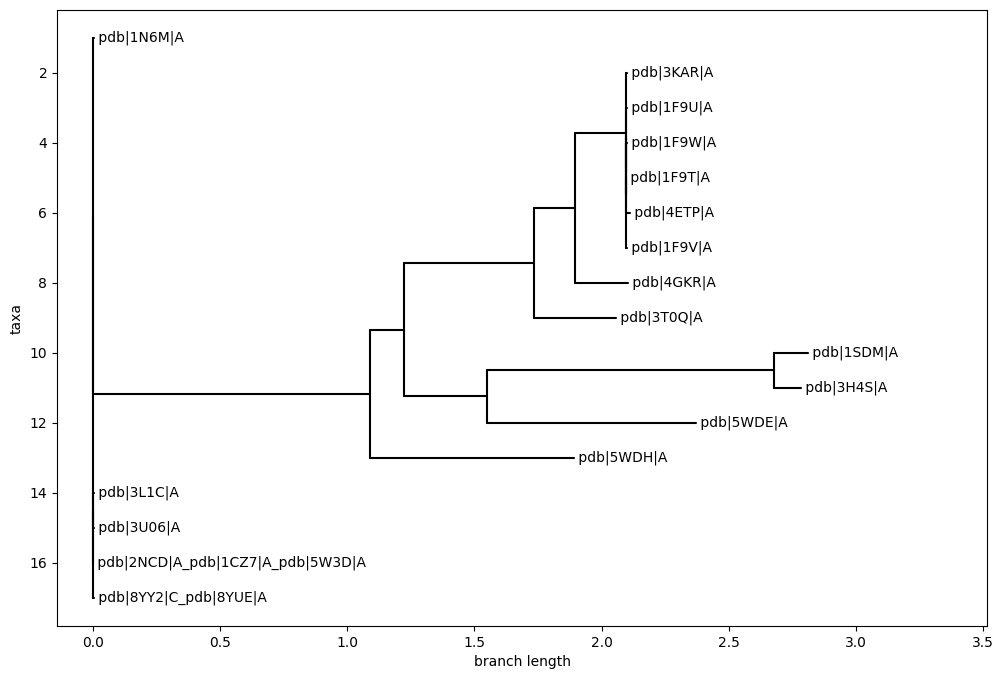

In [17]:
from Bio import Phylo
import matplotlib.pyplot as plt

tree = Phylo.read(
    "K14_TREE.raxml.bestTree",
    "newick"
)

fig, ax = plt.subplots(figsize=(12,8))

Phylo.draw(tree, axes=ax)

plt.show()

In [18]:
!raxml-ng \
--bootstrap \
--msa K14_TREE.raxml.rba \
--model LG+I+G4 \
--prefix K14_BOOT \
--threads 2 \
--bs-tree 100


RAxML-NG v. 2.0.1 released on 24.04.2026 by The Exelixis Lab.
Developed by: Oleksiy M. Kozlov and Alexandros Stamatakis.
Contributors: Diego Darriba, Tomas Flouri, Benoit Morel, Sarah Lutteropp, Ben Bettisworth,
              Julia Haag, Anastasis Togkousidis, Julius Wiegert, Christoph Stelz.
Latest version: https://github.com/amkozlov/raxml-ng
Questions/problems/suggestions? Please visit: https://groups.google.com/forum/#!forum/raxml

System: Intel(R) Xeon(R) CPU @ 2.20GHz, 1 cores, 12 GB RAM

RAxML-NG was called at 10-May-2026 21:56:39 as follows:

raxml-ng --bootstrap --msa K14_TREE.raxml.rba --model LG+I+G4 --prefix K14_BOOT --threads 2 --bs-tree 100

Analysis options:
  run mode: Bootstrapping (adaptive) (Felsenstein Bootstrap)
  start tree(s): 
  bootstrap replicates: parsimony (100)
  random seed: 1778450199
  tip-inner: OFF
  pattern compression: ON
  per-rate scalers: OFF
  site repeats: ON
  logLH epsilon: general: 10.000000, brlen-triplet: 1000.000000
  stopping rule: OFF
 

In [19]:
!raxml-ng \
--support \
--tree K14_TREE.raxml.bestTree \
--bs-trees K14_BOOT.raxml.bootstraps \
--prefix K14_SUPPORT \
--threads 2


RAxML-NG v. 2.0.1 released on 24.04.2026 by The Exelixis Lab.
Developed by: Oleksiy M. Kozlov and Alexandros Stamatakis.
Contributors: Diego Darriba, Tomas Flouri, Benoit Morel, Sarah Lutteropp, Ben Bettisworth,
              Julia Haag, Anastasis Togkousidis, Julius Wiegert, Christoph Stelz.
Latest version: https://github.com/amkozlov/raxml-ng
Questions/problems/suggestions? Please visit: https://groups.google.com/forum/#!forum/raxml

System: Intel(R) Xeon(R) CPU @ 2.20GHz, 1 cores, 12 GB RAM

RAxML-NG was called at 10-May-2026 21:58:53 as follows:

raxml-ng --support --tree K14_TREE.raxml.bestTree --bs-trees K14_BOOT.raxml.bootstraps --prefix K14_SUPPORT --threads 2

Analysis options:
  run mode: Compute bipartition support (Felsenstein Bootstrap)
  start tree(s): user
  random seed: 1778450333
  SIMD kernels: AVX2
  parallelization: coarse-grained (auto), PTHREADS (2 threads), thread pinning: OFF

Reading reference tree from file: K14_TREE.raxml.bestTree
Reference tree size: 17

Re

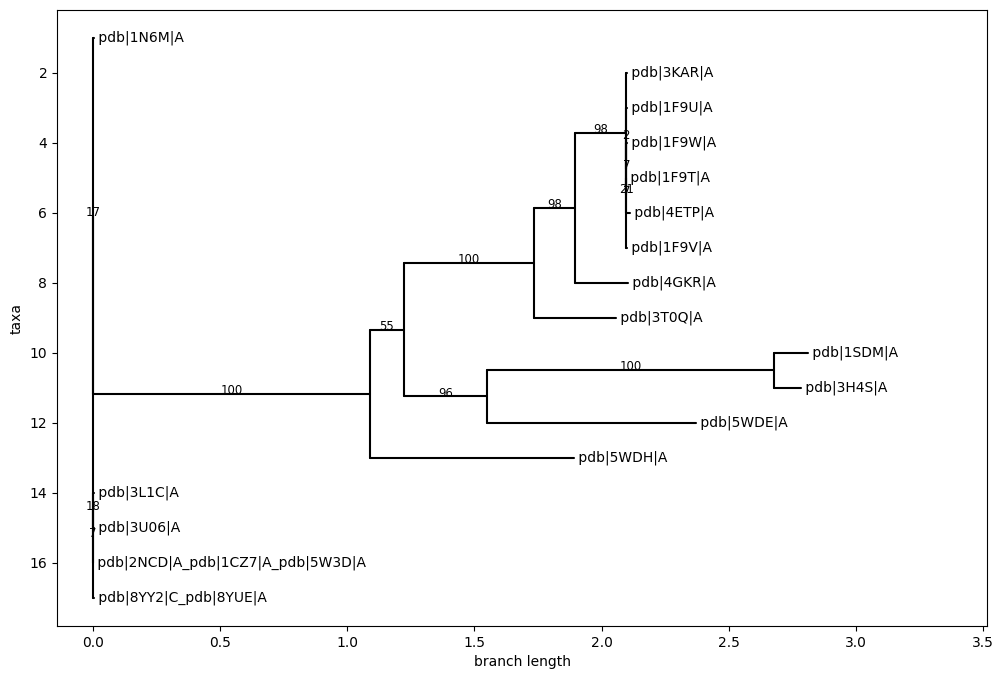

In [20]:
from Bio import Phylo
import matplotlib.pyplot as plt

tree = Phylo.read(
    "K14_SUPPORT.raxml.support",
    "newick"
)

fig, ax = plt.subplots(figsize=(12,8))

Phylo.draw(tree, axes=ax)

plt.show()

In [21]:
!raxml-ng \
--ancestral \
--msa clear_aligned_trimmed_kinesin14.fasta \
--tree K14_TREE.raxml.bestTree \
--model LG+I+G4 \
--prefix K14_ASR


RAxML-NG v. 2.0.1 released on 24.04.2026 by The Exelixis Lab.
Developed by: Oleksiy M. Kozlov and Alexandros Stamatakis.
Contributors: Diego Darriba, Tomas Flouri, Benoit Morel, Sarah Lutteropp, Ben Bettisworth,
              Julia Haag, Anastasis Togkousidis, Julius Wiegert, Christoph Stelz.
Latest version: https://github.com/amkozlov/raxml-ng
Questions/problems/suggestions? Please visit: https://groups.google.com/forum/#!forum/raxml

System: Intel(R) Xeon(R) CPU @ 2.20GHz, 1 cores, 12 GB RAM

RAxML-NG was called at 10-May-2026 21:58:53 as follows:

raxml-ng --ancestral --msa clear_aligned_trimmed_kinesin14.fasta --tree K14_TREE.raxml.bestTree --model LG+I+G4 --prefix K14_ASR

Analysis options:
  run mode: Ancestral state reconstruction
  start tree(s): user
  random seed: 1778450333
  tip-inner: ON
  pattern compression: OFF
  per-rate scalers: OFF
  site repeats: OFF
  logLH epsilon: general: 0.100000, brlen-triplet: 1000.000000
  branch lengths: proportional (ML estimate, algorith

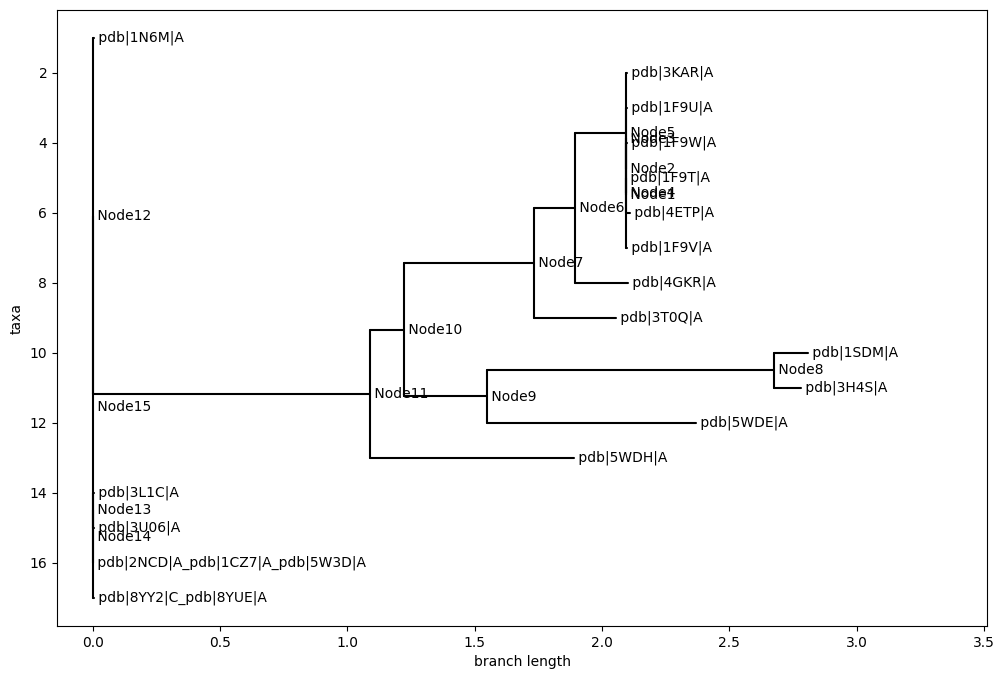

In [22]:
from Bio import Phylo
import matplotlib.pyplot as plt

tree = Phylo.read(
    "K14_ASR.raxml.ancestralTree",
    "newick"
)

fig, ax = plt.subplots(figsize=(12,8))

Phylo.draw(tree, axes=ax)

plt.show()